<a href="https://colab.research.google.com/github/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/blob/main/Lab3/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 3**

En este laboratorio trabajarás con el modelo de *regresión lineal simple*.

In [28]:
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

## **Pregunta 1**

Descarga datos mensuales desde Yahoo Finance para el precio de cierre ajustado de *Amylyx Pharmaceuticals, Inc. (AMLX)* y el valor del *S&P500 (^GSPC)* para el período *Enero 2022-Agosto 2026*.


In [29]:
tickers = ['AMLX', '^GSPC']
datos = yf.download(tickers, start='2022-01-01', end='2026-08-16', interval='1mo', auto_adjust=True)['Close']

[*********************100%***********************]  2 of 2 completed


## **Pregunta 2**

Presenta las primeras 15 y las últimas 10 observaciones.

In [30]:
print(datos[['AMLX', '^GSPC']].head(15))

Ticker           AMLX        ^GSPC
Date                              
2022-01-01  23.180000  4515.549805
2022-02-01  32.900002  4373.939941
2022-03-01  12.850000  4530.410156
2022-04-01   9.000000  4131.930176
2022-05-01   8.890000  4132.149902
2022-06-01  19.260000  3785.379883
2022-07-01  26.990000  4130.290039
2022-08-01  25.240000  3955.000000
2022-09-01  28.150000  3585.620117
2022-10-01  35.669998  3871.979980
2022-11-01  38.369999  4080.110107
2022-12-01  36.950001  3839.500000
2023-01-01  39.189999  4076.600098
2023-02-01  34.820000  3970.149902
2023-03-01  29.340000  4109.310059


In [31]:
print(datos[['AMLX', '^GSPC']].tail(10))

Ticker           AMLX        ^GSPC
Date                              
2025-11-01  14.980000  6849.089844
2025-12-01  12.080000  6845.500000
2026-01-01  14.290000  6939.029785
2026-02-01  15.170000  6878.879883
2026-03-01  13.900000  6528.520020
2026-04-01  16.000000  7209.009766
2026-05-01  14.350000  7580.060059
2026-06-01  17.959999  7499.359863
2026-07-01  20.309999  7489.720215
2026-08-01  21.629999  7785.759766


 ## **Pregunta 3**

 Construye un gráfico de líneas con ambas series normalizadas, donde el valor de enero de 2022 es 100.

In [16]:
# Normalizando series a 100 en Enero 2022

amlx_ene_2022 = datos.loc['2022-01-01', 'AMLX'] # precio base = 100
gspc_ene_2022 = datos.loc['2022-01-01', '^GSPC'] # valor del índice base = 100

datos_normalizados = datos.copy()
datos_normalizados['AMLX_norm'] = (datos_normalizados['AMLX'] / amlx_ene_2022) * 100
datos_normalizados['^GSPC_norm'] = (datos_normalizados['^GSPC'] / gspc_ene_2022) * 100

datos_normalizados[['AMLX_norm', '^GSPC_norm']].tail(1)  # datos de agosto 2026


Ticker,AMLX_norm,^GSPC_norm
Date,,
2026-08-01,93.313196,172.421081


**Enero 2022**

- AMLX: 23.18

- S&P500: 4515.55

**Agosto 2026**

- AMLX: 21.63

- S&P500: 7785.76

Por lo tanto, los valores de AMLX y S&P500 en agosto 2026 son 93.31 y 172.42, respectivamente.

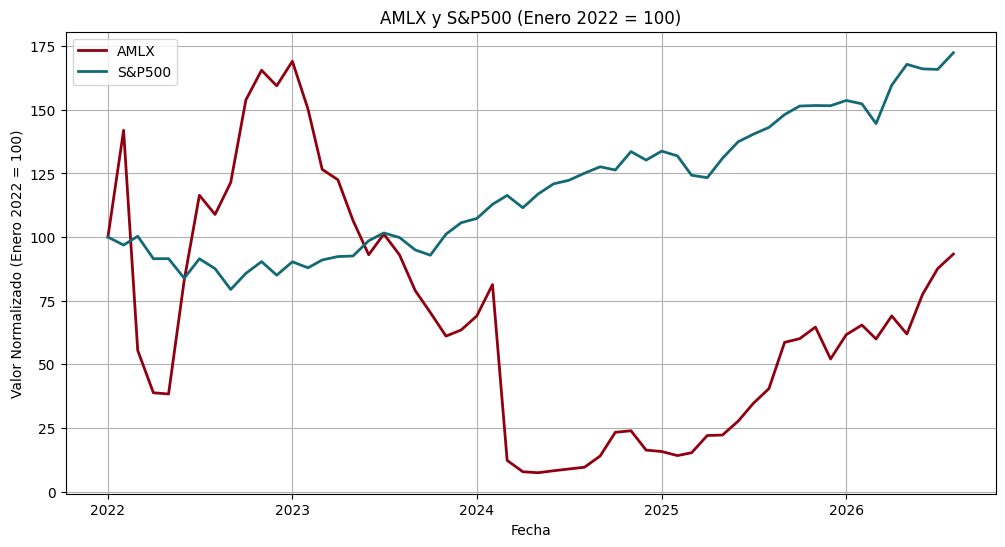

In [29]:
# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(datos_normalizados.index, datos_normalizados['AMLX_norm'],
         label='AMLX', color='#910010', linewidth=2)
plt.plot(datos_normalizados.index, datos_normalizados['^GSPC_norm'],
         label='S&P500', color='#136A75', linewidth=2)

plt.title('AMLX y S&P500 (Enero 2022 = 100)')
plt.xlabel('Fecha')
plt.ylabel('Valor Normalizado (Enero 2022 = 100)')
plt.legend()
plt.grid(True)
plt.show()

## **Pregunta 4**

Calcula los retornos mensuales de la acción de AMLX y de S&P500.

In [10]:
# Calcular retornos porcentuales mensuales
retornos = datos.pct_change().dropna()
retornos['R_AMLX'] = retornos['AMLX']*100
retornos['R_M'] = retornos['^GSPC']*100

In [11]:
print(retornos[['R_AMLX', 'R_M']].head(10))

Ticker          R_AMLX       R_M
Date                            
2022-02-01   41.932705 -3.136049
2022-03-01  -60.942250  3.577329
2022-04-01  -29.961092 -8.795671
2022-05-01   -1.222218  0.005318
2022-06-01  116.647913 -8.392000
2022-07-01   40.134992  9.111639
2022-08-01   -6.483883 -4.244013
2022-09-01   11.529318 -9.339567
2022-10-01   26.714027  7.986341
2022-11-01    7.569389  5.375289


- El retorno de AMLX en febrero 2022 es $\frac{32.90-23.18}{23.18}\times 100=41.93\%$

- El retorno del S&P500 en febrero 2022 es $\frac{4373.94-4515.55}{4515.55}\times 100=-3.14\%$

## **Pregunta 5**

Presenta estadística descriptiva de los retornos mensuales de AMLX y S&P500.

In [12]:
resumen = (retornos[['R_AMLX', 'R_M']]).agg([
    'count', 'mean', 'std', 'min', lambda x: x.quantile(0.25), 'median', lambda x: x.quantile(0.75), 'max'])

resumen.index = [
    'Observaciones', 'Media (%)', 'Desv. Estándar (%)', 'Mínimo (%)', 'Q1 (%)', 'Mediana (%)', 'Q3 (%)', 'Máximo (%)']

resumen.round(2)

Ticker,R_AMLX,R_M
Observaciones,55.00,55.00
Media (%),5.01,1.10
Desv. Estándar (%),29.53,4.55
Mínimo (%),-84.93,-9.34
Q1 (%),-10.22,-1.60
Mediana (%),6.06,1.59
Q3 (%),15.96,4.19
Máximo (%),116.65,10.42


## **Pregunta 6**

Calcula la matriz de varianza y covarianza y matriz de correlación entre los retornos de AMLX y del S&P500.

In [13]:
retornos[['R_AMLX', 'R_M']].cov()


Ticker,R_AMLX,R_M
Ticker,,
R_AMLX,872.112359,-4.116550
R_M,-4.116550,20.660267


Nota que la diagonal principal representa a las varianzas y la covarianza corresponde al elemento de la matriz que se encuentra fuera de la diagonal principal.

In [25]:
retornos[['R_AMLX', 'R_M']].corr()

Ticker,R_AMLX,R_M
Ticker,,
R_AMLX,1.000000,-0.030668
R_M,-0.030668,1.000000


Nota que:

$$r=\frac{-4.1166}{\sqrt{872.1124}\sqrt{20.6603}}=-0.0307$$

## **Pregunta 7**

Construye un gráfico de dispersión de los retornos

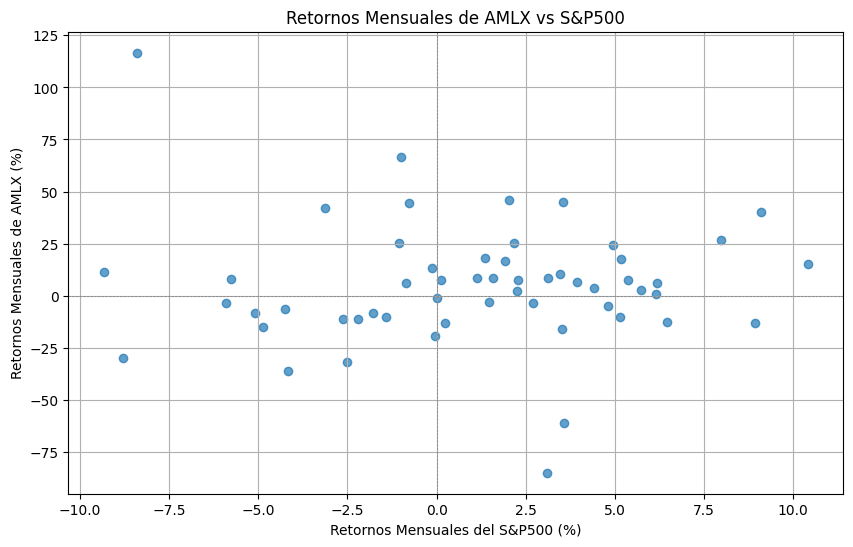

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(retornos['R_M'], retornos['R_AMLX'], alpha=0.7)
plt.title('Retornos Mensuales de AMLX vs S&P500')
plt.xlabel('Retornos Mensuales del S&P500 (%)')
plt.ylabel('Retornos Mensuales de AMLX (%)')
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.show()

## **Pregunta 8**

Usando datos mensuales, estima por MCO el siguiente modelo para el período Agosto 2021 hasta Agosto 2026:

$$R_{AMLX}=\alpha+\beta R_{M}+u$$

donde:

$R_{AMLX}$ es el retorno mensual de la acción de *Amylyx Pharmaceuticals*.

$R_{M}$ es el retorno mensual del S&P500.

Interpreta el valor del $\widehat\beta$.


In [15]:
retornos_con_constante = sm.add_constant(retornos)
modelo1 = sm.OLS(retornos_con_constante['R_AMLX'], retornos_con_constante[['const', 'R_M']]).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:                 R_AMLX   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.018
Method:                 Least Squares   F-statistic:                   0.04989
Date:                Sun, 16 Aug 2026   Prob (F-statistic):              0.824
Time:                        12:46:25   Log-Likelihood:                -263.71
No. Observations:                  55   AIC:                             531.4
Df Residuals:                      53   BIC:                             535.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2287      4.135      1.265      0.2

## **Pregunta 9**

Testea la siguiente hipótesis:

$H_0:\beta=0$

$H_1:\beta\neq 0$

Usando un nivel de significancia del 1\% ¿Qué puedes concluir?

Esta pregunta puede ser respondida por uno de los tres métodos siguientes: (1) valor crítico, (2) p-value y (3) intervalo de confianza.

- **Método del valor crítico:**

In [16]:
# Nivel de significancia del 1%
alfa = 0.01

# Grados de libertad (Número de observaciones - Número de parámetros)
df = modelo1.df_resid # df = 55 - 2 = 53

In [22]:
# Estadístico t
t_calculado = abs((modelo1.params['R_M'] - 0) / modelo1.bse['R_M'])

# Valor crítico t para un test de dos colas
t_critico = abs(stats.t.ppf(alfa/2, df))

# Nota que se calculó el valor absoluto

print(f"Estadístico t (valor calculado): {t_calculado:.3f}")
print(f"Estadístico t (valor crítico): {t_critico:.3f}")

Estadístico t (valor calculado): 0.223
Estadístico t (valor crítico): 2.672


Dado que $t_{calc} < t_{critico}$, no se rechaza $H_0$.

- **Método del p-value:**

In [23]:
p_value = 2*(1 - stats.t.cdf(t_calculado, df)) # p-value prueba de 2 colas
print(f"p-value: {p_value:.5f}")

p-value: 0.82411


Dado que $0.824 > 0.01$, no se rechaza $H_0$.

- **Método del intervalo de confianza:**

In [25]:
limite_inferior = modelo1.params['R_M'] - t_critico * modelo1.bse['R_M']
limite_superior = modelo1.params['R_M'] + t_critico * modelo1.bse['R_M']
print(f"Intervalo de confianza: [{limite_inferior:.3f}, {limite_superior:.3f}]")

Intervalo de confianza: [-2.583, 2.184]


Dado que el IC incluye el cero, no se rechaza $H_0$.

Nota que al disminuir el nivel de significancia $(\alpha)$, aumenta el ancho del intervalo (compara con IC incluido en el resultado de la *Pregunta 8*).

## **Pregunta 10**

Calcula el $R^2$ como el cuadrado de la correlación $(r^2)$. Compara este valor con el obtenido en la *Pregunta 8*. Interpreta el valor del $R^2$. ¿Cómo se relaciona con el gráfico de dispersión de la *Pregunta 7*?

In [27]:
r = -0.030668  # correlación entre los retornos de la acción y el mercado
print(f"El cuadrado del coeficiente de correlación es: {r**2:.3f}")

El cuadrado del coeficiente de correlación es: 0.001


Por lo tanto, $R^2=r^2$ en el modelo de regresión lineal simple.